# 04 — Kuhn Poker (3 jugadores): CFR e ISMCTS

**Obligatorio 2 — Sistemas Multiagente**

Versión de **3 jugadores** del Kuhn Poker. Baraja J, Q, K, A; una carta oculta por
jugador; acciones *pass* (p) / *bet* (b). El orden de juego se fija con
`play_order` (una permutación de `[0, 1, 2]`).

A diferencia del caso de 2 jugadores, el Kuhn de 3 jugadores **no tiene un único
equilibrio de Nash** y aparecen efectos de **posición/orden** y de coordinación
implícita entre rivales. Validamos que CFR **N-agente** entrena de forma estable y
analizamos el reparto de recompensas (suma cero) y el efecto de la posición.


In [1]:
import sys, os
try:
    ROOT = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    ROOT = os.getcwd()                            # Jupyter / fallback
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz del proyecto:", ROOT)

Raiz del proyecto: C:\Users\joaco\Documents\ort\semestre_3\obligatorio2-sma\obligatorio_2_joaco


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from games.kuhn3 import KuhnPoker3
from agents.cfr import CounterFactualRegret
from agents.ismcts import ISMCTS
from agents.agent_random import RandomAgent
from utils import run_games

np.random.seed(42)
NITER = 600
print("Agentes:", KuhnPoker3(play_order=[0, 1, 2]).agents)

Agentes: ['agent_0', 'agent_1', 'agent_2']


## 1. Entrenamiento de CFR (self-play, 3 agentes)

In [3]:
game = KuhnPoker3(play_order=[0, 1, 2])
cfrs = {a: CounterFactualRegret(game, a) for a in game.agents}
for a, ag in cfrs.items():
    ag.train(niter=NITER)
    print(f"  {a}: {len(ag.node_dict)} info sets")

res = run_games(game, cfrs, 1500)
mean_by_agent = {a: float(np.mean(res['rewards'][a])) for a in game.agents}
print("Recompensa media por jugador (CFR self-play):", {k: round(v, 3) for k, v in mean_by_agent.items()})
print("Suma (debe ~0):", round(sum(mean_by_agent.values()), 3))

  agent_0: 48 info sets


  agent_1: 48 info sets


  agent_2: 48 info sets


Recompensa media por jugador (CFR self-play): {'agent_0': -0.028, 'agent_1': -0.011, 'agent_2': 0.039}
Suma (debe ~0): -0.0


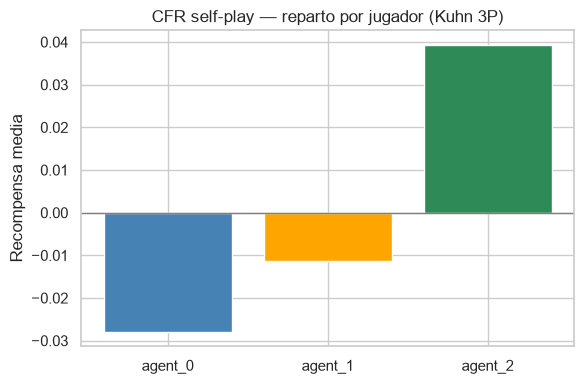

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(mean_by_agent.keys()), list(mean_by_agent.values()),
       color=['steelblue', 'orange', 'seagreen'])
ax.axhline(0, color='gray', lw=1)
ax.set(ylabel='Recompensa media', title='CFR self-play — reparto por jugador (Kuhn 3P)')
plt.tight_layout(); plt.show()

**Convergencia.** El reparto puntual depende de las cartas repartidas; para ver que
CFR *converge* (no solo un número final) seguimos la recompensa media de cada
jugador a lo largo de las iteraciones. En 3 jugadores no existe un Nash único, pero
las curvas deben **estabilizarse** y la suma mantenerse en ~0 (juego de suma cero).

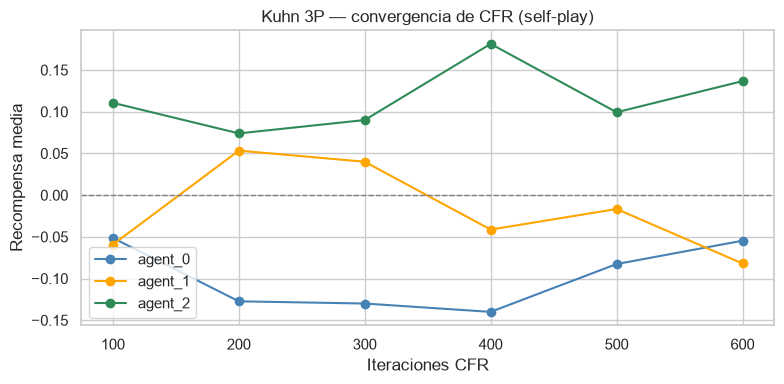

Reparto final: {'agent_0': -0.055, 'agent_1': -0.082, 'agent_2': 0.137} | suma: -0.0


In [5]:
# Curva de convergencia: reward medio de cada jugador a lo largo del entrenamiento.
# En 3 jugadores no hay un Nash unico, pero el reparto debe ESTABILIZARSE y sumar ~0.
gc = KuhnPoker3(play_order=[0, 1, 2])
cfrs_c = {a: CounterFactualRegret(gc, a) for a in gc.agents}
CHECK_C, TOTAL_C, N_EVAL_C = 100, 600, 1500
iters_c, rew_c = [], {a: [] for a in gc.agents}
for i in range(0, TOTAL_C, CHECK_C):
    for ag in cfrs_c.values():
        ag.train(niter=CHECK_C)
    r = run_games(gc, cfrs_c, N_EVAL_C)
    iters_c.append(i + CHECK_C)
    for a in gc.agents:
        rew_c[a].append(float(np.mean(r['rewards'][a])))

fig, ax = plt.subplots(figsize=(8, 4))
for a, c in zip(gc.agents, ['steelblue', 'orange', 'seagreen']):
    ax.plot(iters_c, rew_c[a], '-o', color=c, label=a)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set(xlabel='Iteraciones CFR', ylabel='Recompensa media',
       title='Kuhn 3P — convergencia de CFR (self-play)')
ax.legend(); plt.tight_layout(); plt.show()
print("Reparto final:", {a: round(rew_c[a][-1], 3) for a in gc.agents},
      "| suma:", round(sum(rew_c[a][-1] for a in gc.agents), 3))

## 2. Efecto de la posición (orden de juego)

Variamos qué jugador **abre** la mano rotando `play_order` y medimos la recompensa
media de cada jugador (entrenando CFR en *self-play* para cada orden).

In [6]:
rows = []
for opener in [0, 1, 2]:
    order = [(opener + k) % 3 for k in range(3)]
    g = KuhnPoker3(play_order=order)
    ags = {a: CounterFactualRegret(g, a) for a in g.agents}
    for ag in ags.values():
        ag.train(niter=NITER)
    r = run_games(g, ags, 1200)
    rows.append({'abre': f'agent_{opener}',
                 **{a: round(float(np.mean(r['rewards'][a])), 3) for a in g.agents}})
df_pos = pd.DataFrame(rows)
df_pos

,abre,agent_0,agent_1,agent_2
0,agent_0,-0.034,-0.064,0.098
1,agent_1,0.023,-0.086,0.062
2,agent_2,-0.042,0.062,-0.020


## 3. CFR vs ISMCTS vs Random

Mezclamos tipos de agente para ver quién explota a quién: un CFR entrenado frente a
dos rivales aleatorios, frente a dos ISMCTS, y la referencia de tres aleatorios.

In [7]:
def train_cfr_for(game, agent, niter=NITER):
    ag = CounterFactualRegret(game, agent); ag.train(niter=niter); return ag

g = KuhnPoker3(play_order=[0, 1, 2])
ags = {'agent_0': train_cfr_for(g, 'agent_0'),
       'agent_1': RandomAgent(g, 'agent_1'), 'agent_2': RandomAgent(g, 'agent_2')}
r = run_games(g, ags, 1500)
print("CFR vs 2 Random  -> reward CFR:", round(float(np.mean(r['rewards']['agent_0'])), 3))

g = KuhnPoker3(play_order=[0, 1, 2])
ags = {'agent_0': train_cfr_for(g, 'agent_0'),
       'agent_1': ISMCTS(g, 'agent_1', simulations=150),
       'agent_2': ISMCTS(g, 'agent_2', simulations=150)}
r = run_games(g, ags, 300)
print("CFR vs 2 ISMCTS  -> reward CFR:", round(float(np.mean(r['rewards']['agent_0'])), 3))

g = KuhnPoker3(play_order=[0, 1, 2])
ags = {a: RandomAgent(g, a) for a in g.agents}
r = run_games(g, ags, 1500)
print("3 Random         -> reward agent_0:", round(float(np.mean(r['rewards']['agent_0'])), 3))

CFR vs 2 Random  -> reward CFR: 0.372


CFR vs 2 ISMCTS  -> reward CFR: -0.09


3 Random         -> reward agent_0: 0.129


### Barrido de simulaciones de ISMCTS (3 jugadores)

Igual que en Kuhn 2P, variamos el presupuesto de simulaciones de ISMCTS para ver el
compromiso desempeño/costo, ahora en la mesa de 3 jugadores (ISMCTS contra dos
rivales aleatorios).

  sims=50: reward=0.727, t/partida=0.06s


  sims=150: reward=0.52, t/partida=0.182s


  sims=300: reward=0.613, t/partida=0.336s


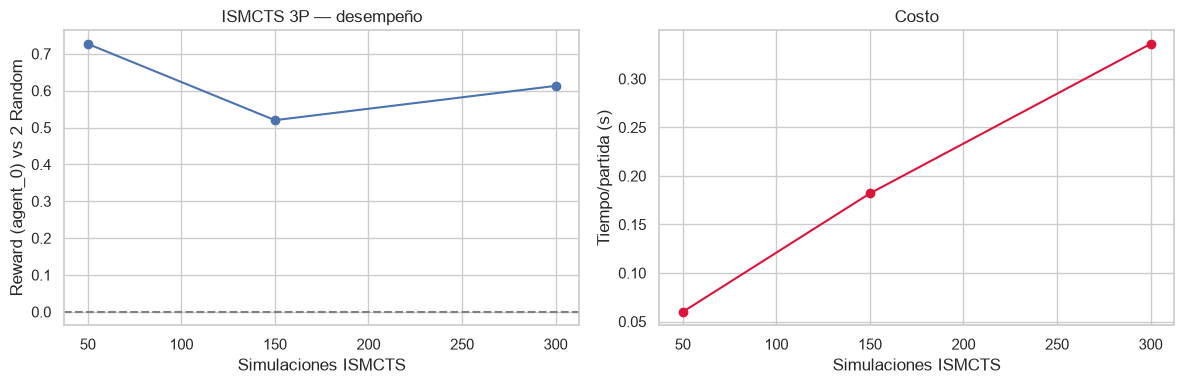

,sims,reward_ISMCTS,time_per_game
0,50,0.727,0.060
1,150,0.520,0.182
2,300,0.613,0.336


In [8]:
# Sweep de simulaciones de ISMCTS en 3 jugadores (ISMCTS como agent_0 vs 2 Random).
import time
rows = []
for s in [50, 150, 300]:
    g = KuhnPoker3(play_order=[0, 1, 2])
    ags = {'agent_0': ISMCTS(g, 'agent_0', simulations=s),
           'agent_1': RandomAgent(g, 'agent_1'),
           'agent_2': RandomAgent(g, 'agent_2')}
    t0 = time.time()
    r = run_games(g, ags, 150)
    dt = time.time() - t0
    rows.append({'sims': s,
                 'reward_ISMCTS': round(float(np.mean(r['rewards']['agent_0'])), 3),
                 'time_per_game': round(dt / 150, 3)})
    print(f"  sims={s}: reward={rows[-1]['reward_ISMCTS']}, t/partida={rows[-1]['time_per_game']}s")
df_is3 = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df_is3.sims, df_is3.reward_ISMCTS, 'o-'); ax[0].axhline(0, color='gray', ls='--')
ax[0].set(xlabel='Simulaciones ISMCTS', ylabel='Reward (agent_0) vs 2 Random',
          title='ISMCTS 3P — desempeño')
ax[1].plot(df_is3.sims, df_is3.time_per_game, 'o-', color='crimson')
ax[1].set(xlabel='Simulaciones ISMCTS', ylabel='Tiempo/partida (s)', title='Costo')
plt.tight_layout(); plt.show()
df_is3.round(3)

## Conclusiones — Kuhn Poker (3P)

- CFR **N-agente** entrena de forma estable también con 3 jugadores: el reparto de
  recompensas en *self-play* suma ~0 (juego de suma cero).
- Aparece un claro **efecto de posición/orden**: quién abre condiciona la
  recompensa esperada de cada asiento.
- Un CFR entrenado **explota** a rivales aleatorios; frente a ISMCTS el resultado es
  más parejo, y en 3 jugadores no existe un único Nash, por lo que el desenlace
  depende de las estrategias concretas de los rivales.